In [49]:
exp_name = 'gmd_radiative_convective_1420w_10min' #'64x32_4h_400w' 'gmd_radiative_convective_1420w_10min'
exp_folder_name = 'column_code_with_slab' # 'column_code_with_slab' 'gmd_aquaplanet' 'column_rrtmg' 'aquaplanet_RCE_single'
emulate = 'conv' # 'conv' 'rad'
# best_model_path = f"./{exp_folder_name}/best_model_offline/best_model_trial_21.pth"
# best_model_path = f"./{exp_folder_name}/best_model/best_model_trial_0.pth"
ml_exp_name = 'best_model'+ '_' + emulate
best_model_path = f"./{exp_folder_name}/{ml_exp_name}/trial_1.pth"
# norm_path = f'/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/normalization.pth'
import climt
from sympl import DataArray, TendencyComponent, AdamsBashforth, ImplicitTendencyComponent
from sympl import (
    PlotFunctionMonitor, NetCDFMonitor,
    TimeDifferencingWrapper, UpdateFrequencyWrapper,
    set_constant, get_constant, initialize_numpy_arrays_with_properties
)
import gfs_dynamical_core
from datetime import timedelta
import numpy as np
import torch
import torch.nn as nn
import sys, os, pickle
from climt import (
    EmanuelConvection, RRTMGShortwave, RRTMGLongwave, SlabSurface,
    DryConvectiveAdjustment, SimplePhysics, get_default_state
)
from datetime import timedelta
import xarray as xr
import matplotlib.pyplot as plt
sys.path.append("..")
from models import DynamicMLP, DynamicMLP_flatten, DynamicMLP_flatten_maskq

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

norm = torch.load(f'/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/normalization.pth', weights_only=True,map_location=device)
X_mean = norm['X_mean'] # [C]
X_std  = norm['X_std']
X_max  = norm['X_max']
X_min  = norm['X_min']
y_mean = norm['y_mean']
y_std  = norm['y_std']
y_max  = norm['y_max']
y_min  = norm['y_min']

X_std_safe = X_std.clone()
X_std_safe[X_std_safe == 0.0] = 1.0
y_std_safe = y_std.clone()
y_std_safe[y_std_safe == 0.0] = 1.0

X_den = (X_max - X_min).clone()
X_den[X_den == 0.0] = 1.0
y_den = (y_max - y_min).clone()
y_den[y_den == 0.0] = 1.0

def log_transform(x, eps, scale):
    return torch.sign(x) * torch.log1p(torch.abs(x) / eps) / scale
def inv_log_transform(x_n, eps, scale):
    # inverse of sign(x)*log1p(|x|/eps)/10
    return torch.sign(x_n) * torch.expm1(torch.abs(x_n) * scale) * eps

# class TorchScaler:
#     def __init__(self, mean, std):
#         self.mean = mean  # [C]
#         self.std = std    # [C]

#     def _to_numpy(self, arr):
#         if isinstance(arr, torch.Tensor):
#             return arr.detach().cpu().numpy()
#         return arr

#     def transform(self, x):
#         mean = self._to_numpy(self.mean)
#         std  = self._to_numpy(self.std)
#         # avoid division by zero
#         std_safe = np.where(std == 0.0, 1.0, std)
        
#         return (x - mean) / std_safe

#     def inverse_transform(self, x):
#         mean = self._to_numpy(self.mean)
#         std  = self._to_numpy(self.std)
#         std_safe = np.where(std == 0.0, 1.0, std)

#         return x * std_safe + mean

def check_state(state, step):
    for k, v in state.items():

        # Extract raw numpy array
        if hasattr(v, "values"):
            arr = v.values
        elif isinstance(v, np.ndarray):
            arr = v
        else:
            continue  # skip non-numeric entries (time, metadata, etc.)

        # Skip non-numeric dtypes
        if not np.issubdtype(arr.dtype, np.number):
            continue

        if not np.all(np.isfinite(arr)):
            bad = np.sum(~np.isfinite(arr))
            raise RuntimeError(
                f"NaN/Inf in '{k}' at step {step} "
                f"(bad count={bad})"
            )

In [52]:
class NNParameterization(TendencyComponent):

    input_properties = {
        'air_temperature': {'dims': ['*', 'mid_levels'], 'units': 'degK'},
        'specific_humidity': {'dims': ['*', 'mid_levels'], 'units': 'kg/kg'},
        'surface_air_pressure': {'dims': ['*'], 'units': 'Pa'},
        'surface_upward_latent_heat_flux': {'dims': ['*'], 'units': 'W m^-2'},
        'surface_upward_sensible_heat_flux': {'dims': ['*'], 'units': 'W m^-2'},  
        # 'eastward_wind': {'dims': ['*', 'mid_levels'], 'units': 'm s^-1'},
        # 'northward_wind': {'dims': ['*', 'mid_levels'], 'units': 'm s^-1'},
        # 'air_pressure': {
        #     'dims': ['*', 'mid_levels'],
        #     'units': 'mbar',
        # },
        # 'air_pressure_on_interface_levels': {
        #     'dims': ['*', 'interface_levels'],
        #     'units': 'mbar',
        # },
        # 'cloud_base_mass_flux': {
        #     'dims': ['*'],
        #     'units': 'kg m^-2 s^-1',
        # },
    }
    tendency_properties = {}
    if emulate == 'rad':
        tendency_properties['air_temperature'] = {'units': 'degK day^-1'}
    if emulate == 'conv':
        tendency_properties['air_temperature'] = {'units': 'degK s^-1'}
        tendency_properties['specific_humidity'] = {'units': 'kg/kg s^-1'}

    diagnostic_properties = {}
    if emulate == 'rad':
        diagnostic_properties['air_temperature_tendency_from_NN'] = {'dims': ['*', 'mid_levels'],'units': 'degK day^-1'}
    if emulate == 'conv':
        diagnostic_properties['air_temperature_tendency_from_NN'] = {'dims': ['*', 'mid_levels'],'units': 'degK s^-1'}
        diagnostic_properties['specific_humidity_tendency_from_NN'] = {'dims': ['*', 'mid_levels'],'units': 'kg/kg s^-1'}
        diagnostic_properties['convective_precipitation_rate'] = {'dims': ['*'],'units': 'mm day^-1'}

    def __init__(self, top_k=5, emulate_layer=13, **kwargs):
        super(NNParameterization, self).__init__(**kwargs)

        self.emulate_layer = emulate_layer
        self.top_k = top_k
        
        if emulate == 'rad':
            self.true = RRTMGLongwave()
        if emulate == 'conv':
            self.true = EmanuelConvection(tendencies_in_diagnostics=True)

        if exp_folder_name == 'gmd_aquaplanet' and emulate == 'rad':
            self.IN_FEATURES, self.OUT_FEATURES = 59, 28
        if exp_folder_name == 'gmd_aquaplanet' and emulate == 'conv':
            self.IN_FEATURES, self.OUT_FEATURES = 59-(28-self.emulate_layer)*2, 57-(28-self.emulate_layer)*2
        if exp_folder_name == 'column_code_with_slab' and emulate == 'rad':
            self.IN_FEATURES, self.OUT_FEATURES = 58, 28
        if exp_folder_name == 'column_code_with_slab' and emulate == 'conv':
            self.IN_FEATURES, self.OUT_FEATURES = 58-(28-self.emulate_layer)*2, 57-(28-self.emulate_layer)*2

        ckpt = torch.load(best_model_path, map_location=device)
        # ckpt_norm = torch.load(norm_path, map_location=device)
        # self.input_scaler  = TorchScaler(ckpt_norm['X_mean'], ckpt_norm['X_std'])
        # self.output_scaler = TorchScaler(ckpt_norm['y_mean'], ckpt_norm['y_std'])

        self.model = DynamicMLP_flatten(self.IN_FEATURES,self.OUT_FEATURES,ckpt["hidden_sizes"]).to(device)
        # self.model = DynamicMLP_flatten_maskq(self.IN_FEATURES,self.OUT_FEATURES,ckpt["hidden_sizes"]).to(device)
        self.model.load_state_dict(ckpt["model_state"])
        self.model.eval()

    def __call__(self, state):
        # # make sure Emanuel sees same timestep as the model integrator
        # if hasattr(self, "current_time_step") and self.current_time_step is not None:
        #     self.true_conv.current_time_step = self.current_time_step
    
        # 1) get "true" convection tendencies (DataArrays)
        if emulate == 'rad':
            true_tend, true_diag = self.true(state)
        if emulate == 'conv':
            true_tend, true_diag = self.true(state, timedelta(minutes=10))
        # print(true_diag.keys())
        # print(true_tend)
        # 2) get NN tendencies (DataArrays) by running numpy inference on the same state
        nn_tend, nn_diag = super().__call__(state)  # this will call array_call()
        # print(nn_diag.keys())
        # print(nn_tend['air_temperature'].values.shape)
        # print(nn_tend)
    
        # 3) blend: overwrite TOP layers with true values
        if emulate == 'rad':
            nn_tend['air_temperature'].isel(mid_levels=slice(-self.top_k, None))[:] = true_tend['air_temperature'].isel(mid_levels=slice(-self.top_k, None))
        if emulate == 'conv':
            print(true_tend['air_temperature'], true_tend['specific_humidity'])
            print('-----------------')
            print(nn_tend['air_temperature'], nn_tend['specific_humidity'])
            nn_tend['air_temperature'].isel(mid_levels=slice(self.emulate_layer, None))[:] = \
            true_tend['air_temperature'].isel(mid_levels=slice(self.emulate_layer, None))

            nn_tend['specific_humidity'].isel(mid_levels=slice(self.emulate_layer, None))[:] = \
            true_tend['specific_humidity'].isel(mid_levels=slice(self.emulate_layer, None))

        # dt = 600.0
        # print("NN dT/dt max", float(np.abs(nn_tend['air_temperature']).max()))
        # print("True dT/dt max", float(np.abs(true_tend['air_temperature']).max()))
        # print("NN ΔT per step max", float(np.abs(nn_tend['air_temperature']).max() * dt))
        # print("True ΔT per step max", float(np.abs(true_tend['air_temperature']).max() * dt))
        # print(true_tend['air_temperature'])
        # if emulate == 'conv':
        #     nn_tend['specific_humidity'].isel(mid_levels=slice(-self.top_k, None))[:] = true_tend['specific_humidity'].isel(mid_levels=slice(-self.top_k, None))

        # nn_tend['air_temperature'].values[..., -self.top_k:] = true_tend['air_temperature'].values[..., -self.top_k:]
        # nn_tend['specific_humidity'].values[..., -self.top_k:] = true_tend['specific_humidity'].values[..., -self.top_k:]

        # print(nn_tend['air_temperature'].values)
        # optional: also expose a diagnostic for true top-layer tendencies
        # (only if you define it in diagnostic_properties)
        # nn_diag['air_temperature_tendency_true_top'] = ...
    
        return nn_tend, nn_diag
        
    def array_call(self, state):
        num_cols, num_levs = state['air_temperature'].shape
        
        tendencies = initialize_numpy_arrays_with_properties(
            self.tendency_properties, state, self.input_properties
        )
        diagnostics = initialize_numpy_arrays_with_properties(
            self.diagnostic_properties, state, self.input_properties
        )
        # ---------------------------------
        # Extract state
        # ---------------------------------
        if emulate == 'rad':
            T, q = state['air_temperature'], state['specific_humidity']
        if emulate == 'conv':
            T, q = state['air_temperature'][..., :self.emulate_layer], state['specific_humidity'][..., :self.emulate_layer]
        # print('T',T)
        ps = state['surface_air_pressure']
        lh = state['surface_upward_latent_heat_flux']
        sh = state['surface_upward_sensible_heat_flux']
        # ---------------------------
        # Build NN input [1, var]
        # ---------------------------
        if exp_folder_name == 'gmd_aquaplanet':
            x = np.concatenate([
                T,
                q,
                ps[..., None],
                lh[..., None],
                sh[..., None],
            ], axis=-1)  # ()
        if exp_folder_name == 'column_code_with_slab':
            x = np.concatenate([
                T,
                q,
                lh[..., None],
                sh[..., None],
            ], axis=-1)  # ()
        # Add batch dimension
        x = torch.tensor(x, dtype=torch.float32, device=device)
        # print('original x', x, x.shape)
        
        # x = log_transform(x, eps=1e-12, scale=10.0)
        # X_std_safe = X_std.clone()
        # X_std_safe[X_std_safe == 0.0] = 1.0
        # den = (X_max - X_min).clone()
        # den[den == 0.0] = 1.0
        x = (x - X_min) / X_den
        
        # print('normed x', x, x.shape)
        
        # x = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
        # ---------------------------------
        # NN inference
        # ---------------------------------
        with torch.no_grad():
            # y = self.model(x)   # ()
            # q_raw = torch.Tensor(q).to(device)
            y = self.model(x)
            # y = torch.clamp(y, -3.0, 3.0)
            
        # print('y_before_norm', y, y.shape)

        y = y * y_std_safe + y_mean 
        y = y.cpu().numpy().squeeze()
        
        # print('y_after_norm', y, y.shape)
        # print('-------------------------')
        
        # ---------------------------------
        # Map NN output → temperature tendency (tendencies['air_temperature'] -> [1,col])
        # ---------------------------------
        if y.ndim == 2: # multi-column
            if emulate == 'rad':
                tendencies['air_temperature'][:] = y[:, :num_levs] #shape -> lon*lat, cols
                diagnostics['air_temperature_tendency_from_NN'][:] = y[:, :num_levs] #shape -> lon*lat, cols
            if emulate == 'conv':
                tendencies['air_temperature'][:] = y[:, :self.emulate_layer] #shape -> lon*lat, cols
                diagnostics['air_temperature_tendency_from_NN'][:] = y[:, :self.emulate_layer] #shape -> lon*lat, cols
                tendencies['specific_humidity'][:] = y[:, self.emulate_layer:2*self.emulate_layer] #shape -> lon*lat, cols
                diagnostics['specific_humidity_tendency_from_NN'][:] = y[:, self.emulate_layer:2*self.emulate_layer] #shape -> lon*lat, cols
                diagnostics['convective_precipitation_rate'][:] = y[:, -1] #shape -> lon*lat, cols
        if y.ndim == 1: # single-column
            if emulate == 'rad':
                tendencies['air_temperature'][:] = y[:num_levs] #shape -> cols
                diagnostics['air_temperature_tendency_from_NN'][:] = y[:num_levs] #shape -> cols
            if emulate == 'conv':
                # print(tendencies['air_temperature'][..., :self.emulate_layer].shape)
                # print(y[:self.emulate_layer][None, :].shape)
                tendencies['air_temperature'][..., :self.emulate_layer] = y[:self.emulate_layer][None, :] #shape -> cols
                diagnostics['air_temperature_tendency_from_NN'][..., :self.emulate_layer] = y[:self.emulate_layer][None, :] #shape -> cols
                tendencies['specific_humidity'][..., :self.emulate_layer] = y[self.emulate_layer:2*self.emulate_layer][None, :] #shape -> cols
                diagnostics['specific_humidity_tendency_from_NN'][..., :self.emulate_layer] = y[self.emulate_layer:2*self.emulate_layer][None, :] #shape -> cols
                diagnostics['convective_precipitation_rate'] = y[-1] #shape -> cols
                # print(diagnostics['convective_precipitation_rate'], y[-1])
        return tendencies, diagnostics

In [54]:
scheme = 'nn' #'nn' 'physics'
fields_to_store = ['air_temperature', 'specific_humidity', 'air_pressure', 'surface_temperature',
                   'air_pressure_on_interface_levels','surface_upward_latent_heat_flux',
                   'surface_upward_sensible_heat_flux','surface_air_pressure',
                   'downwelling_shortwave_flux_in_air', #input
                   'convective_precipitation_rate', #diag
                   'air_temperature_tendency_from_NN', 'specific_humidity_tendency_from_NN',
                   'air_temperature_tendency_from_EmanuelConvection', 'specific_humidity_tendency_from_EmanuelConvection', #output
                   'upwelling_shortwave_flux_in_air', 'downwelling_longwave_flux_in_air','upwelling_longwave_flux_in_air',
                   'air_temperature_tendency_from_shortwave', 'air_temperature_tendency_from_longwave']
netcdf_monitor = NetCDFMonitor(f'/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/online_{scheme}.nc',write_on_store=True,store_names=fields_to_store)
# load state from checkpoint
checkpoint_path = f'/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_checkpoint.pkl'
# checkpoint_path = f'/projects/sds-lab/Shuochen/climt/column_code_with_slab/gmd_radiative_convective_1420w_10min_2_checkpoints/ckpt_000059999.pkl'
if os.path.exists(checkpoint_path):
    with open(checkpoint_path, "rb") as f:
        data = pickle.load(f)
    state = data["state"]

if exp_folder_name == 'gmd_aquaplanet':
    set_constant('stellar_irradiance', value=400, units='W m^-2')
    timestep = timedelta(minutes=10)
    # Create components
    convection = climt.EmanuelConvection(tendencies_in_diagnostics=True)
    simple_physics = TimeDifferencingWrapper(climt.SimplePhysics())
    radiation_step = timedelta(hours=1)
    radiation_lw = UpdateFrequencyWrapper(
        climt.RRTMGLongwave(), radiation_step)
    radiation_sw = UpdateFrequencyWrapper(
        climt.RRTMGShortwave(), radiation_step)
    slab_surface = climt.SlabSurface()
    grid = climt.get_grid(nx=64, ny=32)
    nn_component = NNParameterization()
    if scheme == 'physics':
        dycore = gfs_dynamical_core.GFSDynamicalCore(
            [simple_physics, slab_surface, radiation_sw,
             radiation_lw, convection], number_of_damped_levels=5
        )
    if scheme == 'nn':
        if emulate == 'conv':
            dycore = gfs_dynamical_core.GFSDynamicalCore(
                [simple_physics, slab_surface, radiation_sw,
                 radiation_lw, nn_component], number_of_damped_levels=5
            )
        if emulate == 'rad':
            dycore = gfs_dynamical_core.GFSDynamicalCore(
                [simple_physics, slab_surface, radiation_sw,
                 nn_component, convection], number_of_damped_levels=5
            )    
    for i in range(40000):
        diag, state = dycore(state, timestep)
        state.update(diag)
        state['time'] += timestep
          
        if i % 1 == 0:
            print(state['surface_temperature'].mean().values)
        
        netcdf_monitor.store(state)
        check_state(state, i)
        
if exp_folder_name == 'column_code_with_slab':
    set_constant('stellar_irradiance', value=1420, units='W m^-2')
    timestep = timedelta(minutes=10)
    convection = EmanuelConvection(tendencies_in_diagnostics=True)
    radiation_sw = RRTMGShortwave()
    radiation_lw = RRTMGLongwave()
    slab = SlabSurface()
    simple_physics = SimplePhysics()
    # nn component
    nn_component = NNParameterization()

    # state = get_default_state([simple_physics, convection, radiation_lw, radiation_sw, slab])    
    # state['air_temperature'].values[:] = 270
    # state['surface_albedo_for_direct_shortwave'].values[:] = 0.5
    # state['surface_albedo_for_direct_near_infrared'].values[:] = 0.5
    # state['surface_albedo_for_diffuse_shortwave'].values[:] = 0.5
    # state['zenith_angle'].values[:] = np.pi/2.5
    # state['surface_temperature'].values[:] = 300.
    # state['ocean_mixed_layer_thickness'].values[:] = 5
    # state['area_type'].values[:] = 'sea'

    # # right before the loop (or at i==0)
    # true_tend0, true_diag0 = convection(state, timestep)   # or Emanuel call you use
    # nn_tend0, nn_diag0 = nn_component(state)               # calls your NNParameterization
    
    # print("max |dT|:", np.max(np.abs(nn_tend0["air_temperature"] - true_tend0["air_temperature"])))
    # print("max |dQ|:", np.max(np.abs(nn_tend0["specific_humidity"] - true_tend0["specific_humidity"])))

    
    if scheme == 'physics':
        time_stepper = AdamsBashforth([convection, radiation_lw, radiation_sw, slab])
    if scheme == 'nn':
        if emulate == 'conv':
            time_stepper = AdamsBashforth([nn_component, radiation_lw, radiation_sw, slab])
        if emulate == 'rad':
            time_stepper = AdamsBashforth([convection, nn_component, radiation_sw, slab])
            
    for i in range(40000):
        # print(state['surface_albedo_for_direct_shortwave'])
        diagnostics, state = time_stepper(state, timestep)
        state.update(diagnostics)
    
        diagnostics, new_state = simple_physics(state, timestep)
        state.update(diagnostics)
        # state.update(new_state)
    
        state.update(new_state)
        state['time'] += timestep
        state['eastward_wind'].values[:] = 3.
        
        if (i+1) % 100 == 0:
            print(state['surface_temperature'].values)
        
        netcdf_monitor.store(state)
        check_state(state, i)

# state['ocean_mixed_layer_thickness'].values[:] = 50

<xarray.DataArray (lat: 1, lon: 1, mid_levels: 28)>
array([[[-7.81924836e-05,  7.49314366e-06,  1.05639451e-05,
          1.00918526e-05,  9.21690216e-06,  1.24959211e-05,
          1.24970566e-05,  6.73525489e-06,  4.91222831e-06,
          4.85880873e-06,  2.84795579e-06,  1.02551160e-06,
         -2.52410509e-06, -4.65230351e-06, -9.69121053e-07,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00]]])
Dimensions without coordinates: lat, lon, mid_levels
Attributes:
    units:    degK s^-1 <xarray.DataArray (lat: 1, lon: 1, mid_levels: 28)>
array([[[-2.52923812e-07, -1.41896196e-08, -4.67924475e-09,
         -3.04018084e-09, -2.65514617e-09, -2.63866458e-09,
          8.95014173e-10,  1.71421981e-09,  2.32348534e-09,
          3.06461660e-09,  3.63917015e-09,  1.49875089e-09

KeyboardInterrupt: 

## rad-multi-col

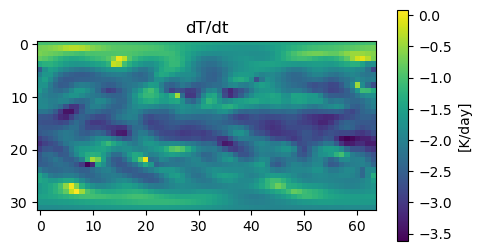

In [26]:
# physics=xr.open_dataset(f'/home/wang.shuoc/climt/{exp_folder_name}/{exp_name}_online_physics.nc')
nn=xr.open_dataset(f'/home/wang.shuoc/climt/{exp_folder_name}/{exp_name}_online_nn.nc')
time_idx = 50
lev_idx = 15

fig = plt.figure(figsize=(12,3))
# ax = fig.add_subplot(1,2,1)
# # ax.plot(physics['air_temperature'].isel(time=time_idx).squeeze(),np.arange(28), label='Emmanuel')
# ax.imshow(nn['air_temperature'].isel(time=time_idx, mid_levels=lev_idx), label='NN')
# ax.set_title('T')
# ax.set_xlabel('[K]')
# ax.set_ylabel(f'lev = {lev_idx}')
# # plt.legend()

ax = fig.add_subplot(1,2,2)
# ax.plot(physics['air_temperature_tendency_from_EmanuelConvection'].isel(time=time_idx).squeeze().values,np.arange(28), label='Emmanuel')
plot=ax.imshow(nn['air_temperature_tendency_from_NN'].isel(time=time_idx, mid_levels=lev_idx), label='NN')
ax.set_title('dT/dt')
cbar = fig.colorbar(plot, ax=ax)
cbar.set_label('[K/day]')
# ax.set_xlim(left=-5e-5)
# plt.legend()

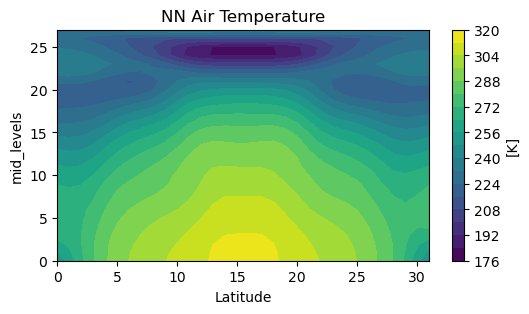

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
# average over longitude
T_nn = nn['air_temperature'].isel(time=time_idx).mean(dim='lon')
# identify vertical dim (safe)
zdim = [d for d in T_nn.dims if d not in ('lat', 'time')][0]
# build coordinates
lat = T_nn['lat']
z   = T_nn[zdim]
# contour plot
cf = ax.contourf(lat,z,T_nn.transpose(zdim, 'lat'),levels=21,cmap='viridis')
# labels
ax.set_title('NN Air Temperature')
ax.set_xlabel('Latitude')
ax.set_ylabel(zdim)
# colorbar
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('[K]')

# rad-single-col

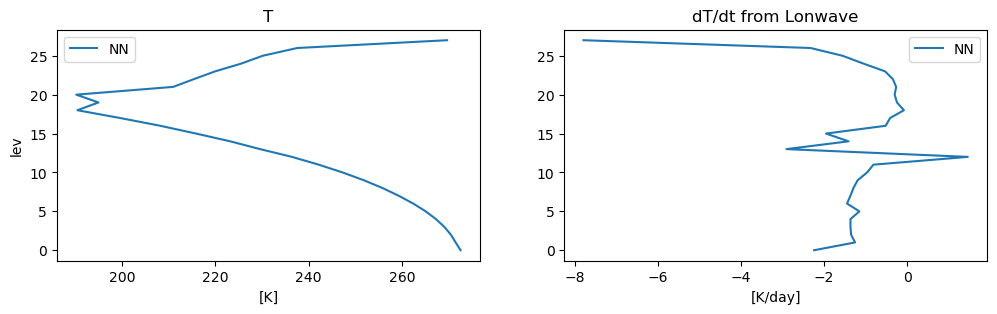

In [12]:
# physics=xr.open_dataset(f'/home/wang.shuoc/climt/{exp_folder_name}/{exp_name}_online_physics.nc')
nn=xr.open_dataset(f'{exp_folder_name}_{exp_name}_online_nn.nc')
time_idx = 30000
lev_idx = 0

fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(1,2,1)
ax.plot(nn['air_temperature'].isel(time=time_idx).squeeze(),np.arange(28), label='NN')
# ax.imshow(nn['air_temperature'].isel(time=time_idx, mid_levels=lev_idx), label='NN')
ax.set_title('T')
ax.set_xlabel('[K]')
ax.set_ylabel('lev')
plt.legend()

ax = fig.add_subplot(1,2,2)
# ax.plot(physics['air_temperature_tendency_from_EmanuelConvection'].isel(time=time_idx).squeeze().values,np.arange(28), label='Emmanuel')
plot=ax.plot(nn['air_temperature_tendency_from_NN'].isel(time=time_idx).squeeze(),np.arange(28), label='NN')
ax.set_title('dT/dt from Longwave')
ax.set_xlabel('[K/day]')
plt.legend()